In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
X,y = make_circles(n_samples = 100,noise = 0.1,random_state = 1)

<Axes: >

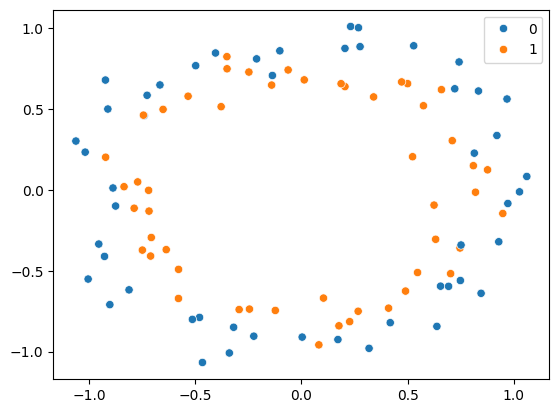

In [4]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue = y)

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42)

In [7]:
model = Sequential()
model.add(Dense(256,input_dim = 2,activation = 'relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics = ['accuracy'])

In [9]:
history = model.fit(X_train,y_train,validation_data = (X_test,y_test),epochs = 3500,verbose = 0)

/tmp/ipykernel_1834/1392355539.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


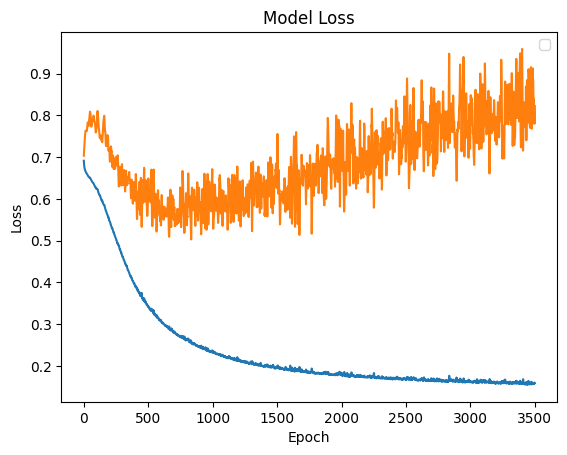

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


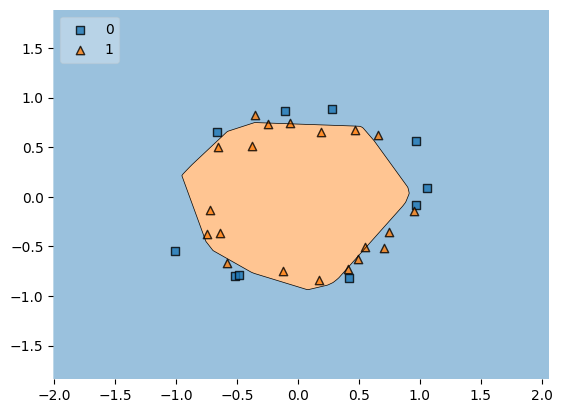

In [11]:
plot_decision_regions(X_test,y_test.ravel(),clf = model,legend = 2)
plt.show()

## Early Stopping

In [12]:
model = Sequential ()
model.add(Dense(256,input_dim =2,activation ='relu'))
model.add(Dense(1,activation = 'sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(loss= 'binary_crossentropy',optimizer = 'adam',metrics = ['accuracy'])

In [14]:
callback = EarlyStopping(
    monitor = 'val_loss',
    min_delta = 0.00001,
    patience = 20,
    verbose = 1,
    mode = 'auto',
    baseline = None,
    restore_best_weights = False
)

In [15]:
history = model.fit(X_train,y_train,validation_data = (X_test,y_test),epochs = 3500,verbose = 0,callbacks = [callback])

Epoch 21: early stopping


/tmp/ipykernel_1834/1392355539.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


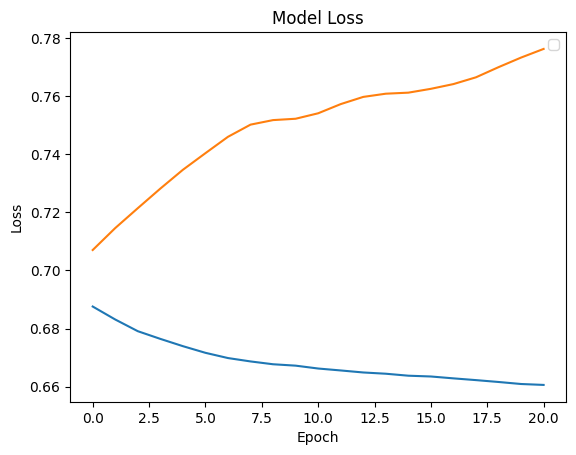

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


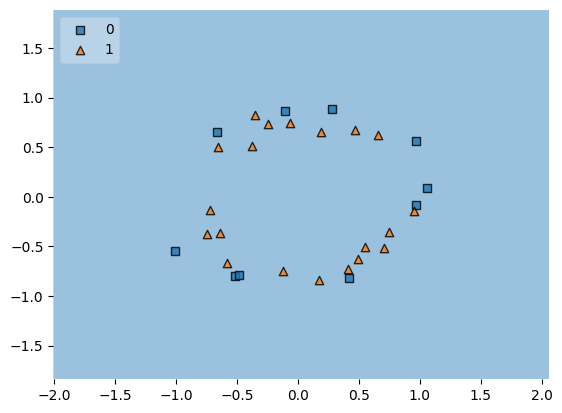

In [17]:
plot_decision_regions(X_test,y_test.ravel(),clf = model,legend = 2)
plt.show()